<a href="https://colab.research.google.com/github/sk6952217-pixel/Day8_Shivam-Kumar_Dataset-annotation-quality-report-correction-plan/blob/main/Day8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import zipfile

zip_path = "/content/Underwater-Image-Data-set-main.zip"
extract_path = "/content/underwater_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

In [4]:
# Install 7zip
!apt-get -qq install p7zip-full

#Dataset folder
dataset = "/content/underwater_dataset/Underwater-Image-Data-set-main"

#Folder where images will be extracted
output = "/content/images"

# Extract all .7z files
!mkdir -p /content/images
!7z x "$dataset/*.7z" -o"$output" -y


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/underwater_dataset/Underwater-Image-Data-set-main/                                                                     8 files, 151077006 bytes (145 MiB)
  0%    
Extracting archive: /content/underwater_dataset/Underwater-Image-Data-set-main/epoch_00100.7z
--
Path = /content/underwater_dataset/Underwater-Image-Data-set-main/epoch_00100.7z
Type = 7z
Physical Size = 31290555
Headers Size = 8080
Method = LZMA:23
Solid = +
Blocks = 1

  0%      1%      3% 57 - epoch_0100/img 118_gen.png                                    

In [5]:
#Count images
import os

#intialize to 0
input_count = 0
target_count = 0
gen_count = 0

#look inside the folder and subfolder
for root, dirs, files in os.walk(dataset):

    for file in files: #check each file one by one

        if "_input.png" in file:  #if file name is "_input.png" input_count increase with 1
            input_count = input_count + 1

        elif "_target.png" in file:  #if file name is "_target.png" target_count increase with 1
            target_count = target_count + 1

        elif "_gen.png" in file:
            gen_count = gen_count + 1

#shows the final count
print("Input images:", input_count)
print("Target images:", target_count)
print("Generated images:", gen_count)
#counts the total
print("Total:", input_count + target_count + gen_count)

Input images: 0
Target images: 0
Generated images: 0
Total: 0


In [6]:
#check dimension
import os
from PIL import Image
from collections import Counter

dataset = "/content/images"

for folder in sorted(os.listdir(dataset)): #loop through each subfolder
    path = os.path.join(dataset, folder)

    if os.path.isdir(path): #Check if the item is actually a directory
        dimensions = []
        for file in os.listdir(path):

            if file.endswith(".png"):# only process png images
                try:
                    img = Image.open(os.path.join(path, file))#open the image and record its width and heigh
                    dimensions.append(img.size)
                except:
                    pass #skip file that fail to open
        count = Counter(dimensions)
        print("\n", folder)
        print("Total images:", len(dimensions))
        print("Dimensions:", dict(count))


 epoch_0096
Total images: 471
Dimensions: {(256, 256): 471}

 epoch_0100
Total images: 465
Dimensions: {(256, 256): 465}

 epoch_0110
Total images: 460
Dimensions: {(256, 256): 460}

 epoch_0115
Total images: 459
Dimensions: {(256, 256): 459}

 epoch_0120
Total images: 459
Dimensions: {(256, 256): 459}

 epoch_0135
Total images: 459
Dimensions: {(256, 256): 459}

 epoch_100
Total images: 462
Dimensions: {(256, 256): 462}


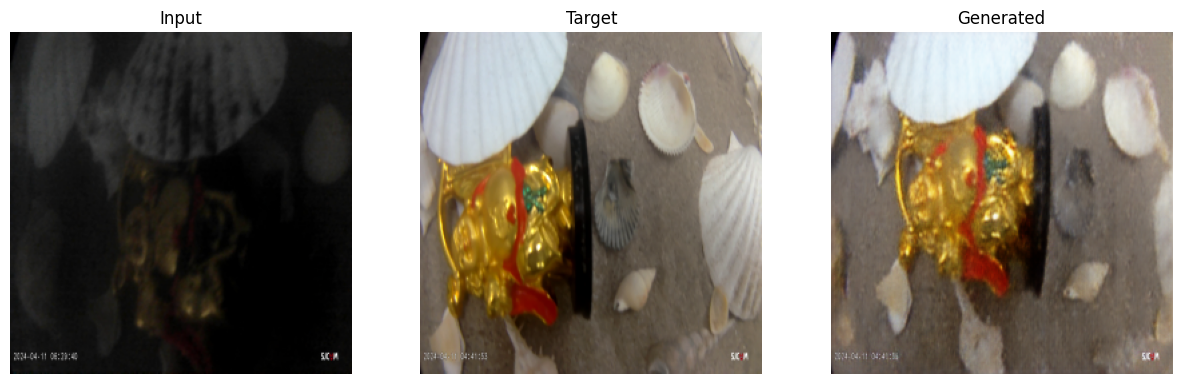

In [7]:
import matplotlib.pyplot as plt

#Start with empty variable to store the file path later
input_img = None
target_img = None
gen_img = None

#look inside the folder and subfolder
for root, dirs, files in os.walk(dataset):
    for file in files: #Check each file one by one

        if "_input.png" in file and input_img is None:  # If it's an input file and we haven't saved one yet
            input_img = os.path.join(root, file)  # Save the full folder path and filename together

        elif "_target.png" in file and target_img is None:  # If it's a target file and we haven't saved one yet
            target_img = os.path.join(root, file)   # Save the full folder path and filename together

        elif "_gen.png" in file and gen_img is None: # If it's a generated file and we haven't saved one yet
            gen_img = os.path.join(root, file)   # Save the full folder path and filename together

        if input_img and target_img and gen_img:  # Inside the file loop: stop checking files if we found all three
            break
    if input_img and target_img and gen_img:  # Inside the folder loop: stop searching folders if we found all three
        break

# Display images
plt.figure(figsize=(15, 5))
images = [input_img, target_img, gen_img]
titles = ["Input", "Target", "Generated"]

for i in range(3):
    img = Image.open(images[i])
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(titles[i])
    plt.axis("off")
plt.show()

In [8]:
# Take one input image
import numpy as np
for root, dirs, files in os.walk(dataset):
   for file in files:
     if "_input.png" in file:

       path = os.path.join(root, file)
       # Open image
       img = Image.open(path).convert("RGB")

       # Resize
       img = img.resize((256, 256))

       # Convert to NumPy array
       img_array = np.array(img)

       # Normalize pixels from 0-255 to 0-1
       img_array = img_array / 255.0

       print("Original size:", Image.open(path).size)
       print("New size:", img.size)
       print("Pixel range:", img_array.min(), "to", img_array.max())
       break
   else:
        continue
   break

Original size: (256, 256)
New size: (256, 256)
Pixel range: 0.0 to 0.9764705882352941


In [9]:
#Check corrupted images
from PIL import Image
from pathlib import Path

folder = Path("/content/images")

images = list(folder.rglob("*.png"))
corrupted = []

for img in images:
    try:
        with Image.open(img) as im:
            im.verify()
    except:
        corrupted.append(img)

print("Corrupted images:", len(corrupted))

for img in corrupted:
    print(img)

Corrupted images: 0


In [10]:
#Check Input / Target / Generated images
inputs = list(folder.rglob("*_input.png"))
targets = list(folder.rglob("*_target.png"))
generated = list(folder.rglob("*_gen.png"))

print("Input images:", len(inputs))
print("Target images:", len(targets))
print("Generated images:", len(generated))

Input images: 1078
Target images: 1078
Generated images: 1078


In [11]:
#Check missing Input–Target pairs
input_ids = {x.stem.replace("_input", "") for x in inputs}
target_ids = {x.stem.replace("_target", "") for x in targets}

missing_targets = input_ids - target_ids
missing_inputs = target_ids - input_ids

print("Inputs without targets:", len(missing_targets))
print("Targets without inputs:", len(missing_inputs))

Inputs without targets: 0
Targets without inputs: 0


In [13]:
#Check filename consistency
other_files = []

for img in images:
    name = img.stem

    if not ("_input" in name or "_target" in name or "_gen" in name):
        other_files.append(img)

print("Files not following input/target/gen naming:", len(other_files))

for img in other_files:
    print(img)

Files not following input/target/gen naming: 0
